### Supplementary Fig. 14: decision tree to filter Hi-C host associations based on known host phyla of VFCs
`virus-mag_HiC_p0.05.tsv` is the output of the Hi-C host association snakemake pipeline, filtered to retain linkages satisfying adjusted p-value < 0.05, and with additional informational columns.

Assumptions:
- The top 12 VFCs and selected reference families have well-defined host phyla. Any host linkages to a different phylum are assumed to be *wrong*.
- Cross-domain host linkages are also assumed to be *wrong*.

The *wrong* class is given a class weight of 100.

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/virus-mag_HiC_p0.05.tsv', sep='\t')
df = df.replace(np.inf, 1) # replace infinite values in 'frac_self_v', 'frac_nonself_m', and 'frac_max_othermag_m' columns with 1

In [3]:
# VFCs with Firmicutes hosts
df_F = df.loc[df.VFC.isin([1,2,4,5,6,7,10,11,12,13,16,35,45])].copy()
df_F['notwrong'] = np.where(df_F.phylum2.str.contains('Firmicutes'), 1, 0)

# VFCs with Bacteroidota hosts
df_B = df.loc[df.VFC.isin([3,43,49,63,67,108,117,123,142,183,242])].copy()
df_B['notwrong'] = np.where(df_B.phylum2 == 'Bacteroidota', 1, 0)

# VFCs with Actinobacteriota hosts
df_A = df.loc[df.VFC.isin([8,9])].copy()
df_A['notwrong'] = np.where(df_A.phylum2 == 'Actinobacteriota', 1, 0)

# inter-domain linkages
df_ID = df.loc[df['num_domains_linked_v_p0.05'] > 1].copy()
df_ID['notwrong'] = np.where(df_ID.domain2 == 'Bacteria', 1, 0)

df1 = pd.concat([df_F, df_B, df_A, df_ID], axis=0, ignore_index=True)

In [4]:
X = df1[['num_linkages',
         'pval_corrected',
         'frac_self_v',
         'frac_nonself_v',
         'frac_self_m',
         'frac_nonself_m',
         'frac_max_othermag_m'
         ]]

y = df1['notwrong']

## Define training and test data

X_train, y_train = X, y

## Run decision tree model

clf = DecisionTreeClassifier(
    max_depth=2,
    # criterion='entropy',
    class_weight={0: 100, 1: 1}
)
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,"{0: 100, 1: 1}"


"Decision boundaries were established at **2.8% viral self-linkages**, followed by **0.065% MAG nonself-linkages**."

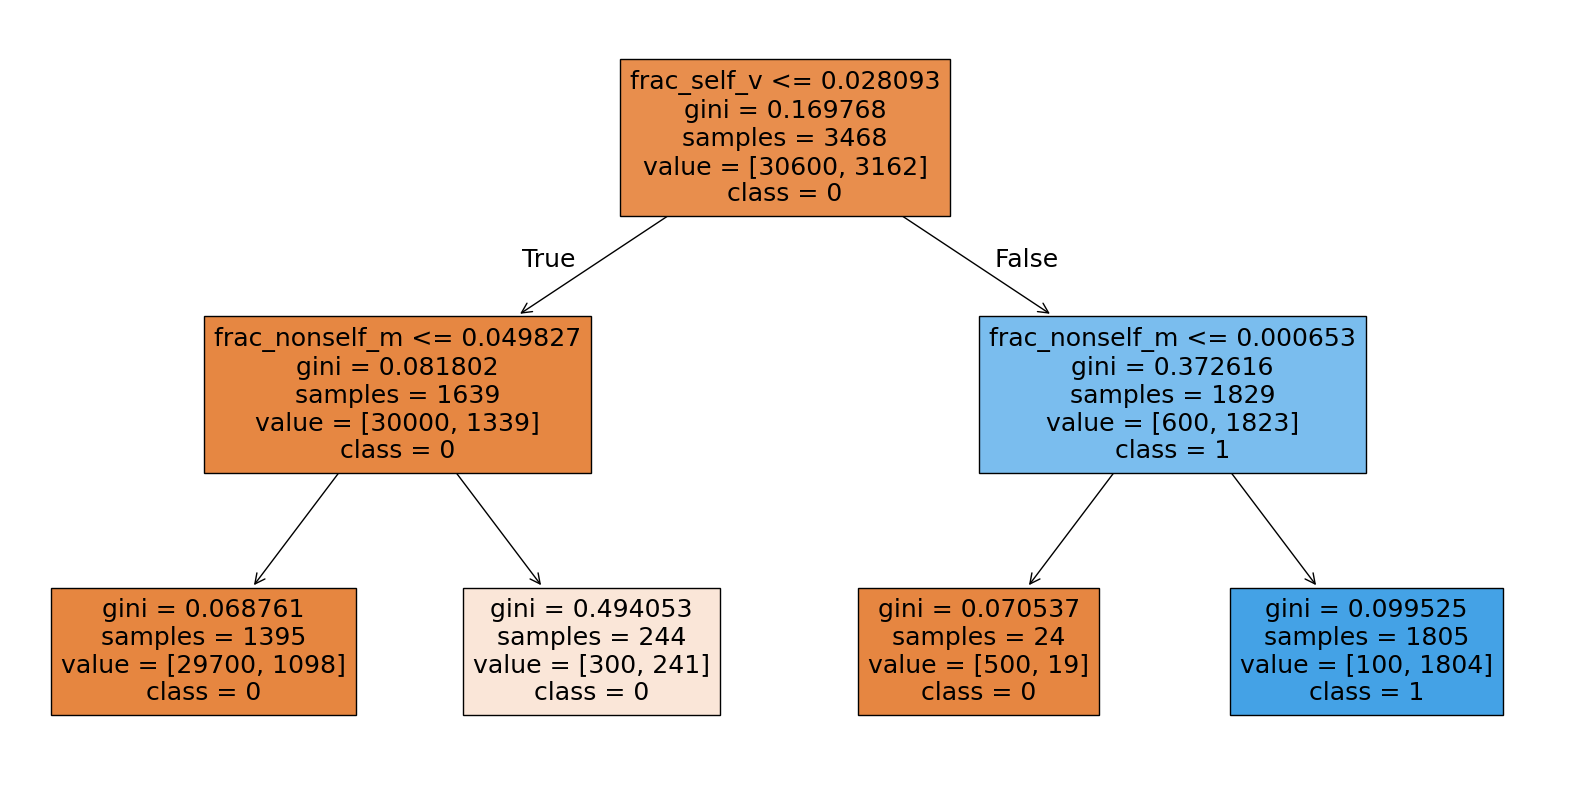

In [5]:
plt.figure(figsize=(20, 10))

plot_tree(
    clf,
    filled=True,
    feature_names=X.columns,
    class_names=[str(c) for c in clf.classes_],
    precision=6
)
plt.show()